In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)

In [2]:
df = pd.read_csv('opt.csv')
df.shape

(823, 172)

In [3]:
df.head()

,rownames,PID,Clinic,Group,Age,Black,White,Nat.Am,Asian,Hisp,Education,Public.Asstce,Hypertension,Diabetes,BL.Diab.Type,BMI,Use.Tob,BL.Cig.Day,Use.Alc,BL.Drks.Day,...,V5.PI,V5.CR,V5.FN,V5.S7,BL..AA,BL..PG,BL..TD,BL..TF,BL..PI,BL..CR,BL..FN,BL..S7,V5..AA,V5..PG,V5..TD,V5..TF,V5..PI,V5..CR,V5..FN,V5..S7
0,1,100034,NY,C,25,Yes,No,No,No,,8-12 yrs,No,N,No,NaN,NaN,Yes,5.0,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,100042,NY,C,21,Yes,No,No,No,,8-12 yrs,Yes,N,No,NaN,21.0,No,NaN,No,NaN,...,NaN,NaN,NaN,NaN,0.01,0.00,3.32,4.79,0.00,2.76,22.15,33.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,100067,NY,T,25,No,Yes,No,No,Yes,8-12 yrs,No,N,No,NaN,24.0,No,NaN,No,NaN,...,NaN,NaN,NaN,NaN,0.00,3.03,1.79,1.15,3.19,1.64,12.51,23.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,100083,NY,C,36,Yes,No,No,No,,MT 12 yrs,Yes,N,No,NaN,36.0,No,NaN,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,100091,NY,C,21,No,Yes,No,No,Yes,8-12 yrs,No,N,No,NaN,27.0,No,NaN,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.tail(3)

,rownames,PID,Clinic,Group,Age,Black,White,Nat.Am,Asian,Hisp,Education,Public.Asstce,Hypertension,Diabetes,BL.Diab.Type,BMI,Use.Tob,BL.Cig.Day,Use.Alc,BL.Drks.Day,...,V5.PI,V5.CR,V5.FN,V5.S7,BL..AA,BL..PG,BL..TD,BL..TF,BL..PI,BL..CR,BL..FN,BL..S7,V5..AA,V5..PG,V5..TD,V5..TF,V5..PI,V5..CR,V5..FN,V5..S7
820,821,402451,MS,C,29,Yes,No,No,No,No,MT 12 yrs,Yes,N,Yes,Type II,36.0,No,NaN,No,NaN,...,0.0,966000.0,27300000.0,33600000.0,0.0,0.0,1.54,5.77,0.0,1.47,22.52,31.31,0.0,0.0,2.37,1.96,0.0,0.79,22.2,27.31
821,822,402469,MS,T,20,Yes,No,No,No,No,8-12 yrs,Yes,N,No,NaN,20.0,Yes,10.0,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
822,823,402477,MS,C,24,Yes,No,No,No,No,MT 12 yrs,Yes,N,No,NaN,18.0,No,NaN,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
cols = ['PID', 'Clinic', 'Group', 'Age', 'BMI', 'N.qualifying.teeth',
        'BL.PD.avg', 'V3.PD.avg', 'V5.PD.avg', 'BL.CAL.avg', 'V5.CAL.avg',
        'GA.at.outcome', 'Birthweight', 'Birth.outcome']
df[cols].describe()

,PID,Age,BMI,N.qualifying.teeth,BL.PD.avg,V3.PD.avg,V5.PD.avg,BL.CAL.avg,V5.CAL.avg,GA.at.outcome,Birthweight
count,823.000000,823.000000,750.000000,823.000000,823.000000,684.000000,659.000000,823.000000,659.000000,823.000000,809.000000
mean,252541.347509,25.978129,27.669333,14.761847,2.865181,2.676588,2.646127,1.412109,1.228715,268.476306,3198.813350
std,106737.056578,5.565973,7.127299,6.747021,0.562013,0.499102,0.499192,0.688277,0.716115,28.252453,683.301508
min,100034.000000,16.000000,15.000000,3.000000,1.851000,1.601000,1.536000,0.185000,0.018000,103.000000,101.000000
25%,200501.000000,22.000000,23.000000,9.000000,2.495500,2.339000,2.301000,0.862000,0.622500,267.000000,2960.000000
50%,202717.000000,25.000000,26.000000,14.000000,2.732000,2.585000,2.565000,1.370000,1.263000,275.000000,3265.000000
75%,302208.000000,30.000000,31.000000,20.000000,3.097500,2.895500,2.877500,1.885000,1.760500,281.000000,3580.000000
max,402477.000000,44.000000,68.000000,28.000000,6.967000,5.464000,5.429000,5.119000,4.350000,302.000000,5160.000000


In [6]:
df['Birth.outcome'].value_counts()

Birth.outcome
Live birth              793
Non-live birth           19
Lost to FU                9
Elective abortion         2
Name: count, dtype: int64

In [7]:
df['OAA5'].unique()[:5]

<StringArray>
['8.264', '.', '2.534', '4.299', '2.122']
Length: 5, dtype: str

In [8]:
text_cols = df.select_dtypes(include='str').columns
print('number of text columns =', len(text_cols))

number of text columns = 73


In [9]:
for col in text_cols:
    df[col] = df[col].str.strip()

df = df.replace('', np.nan)
df = df.replace('.', np.nan)

df['OAA5'].unique()[:5]

<StringArray>
['8.264', nan, '2.534', '4.299', '2.122']
Length: 5, dtype: str

In [10]:
for col in text_cols:
    try:
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        pass

df['OAA5'].dtype

dtype('float64')

In [11]:
df['Birth.outcome'].value_counts()

Birth.outcome
Live birth           793
Non-live birth        19
Lost to FU             9
Elective abortion      2
Name: count, dtype: int64

In [12]:
df['Group'] = df['Group'].replace('C', 'Control')
df['Group'] = df['Group'].replace('T', 'Treatment')
df['Group'].value_counts()

Group
Treatment    413
Control      410
Name: count, dtype: int64

In [13]:
print('duplicated rows =', df.duplicated().sum())
print('duplicated PIDs =', df.duplicated(['PID']).sum())
df.duplicated().head()

duplicated rows = 0
duplicated PIDs = 0


0    False
1    False
2    False
3    False
4    False
dtype: bool

In [14]:
print('rows before =', len(df))
print('rows after drop_duplicates =', len(df.drop_duplicates()))

rows before = 823
rows after drop_duplicates = 823


In [15]:
print('repeated Clinic-Group-Age profiles =', df.duplicated(['Clinic', 'Group', 'Age']).sum())
print('different profiles =', len(df.drop_duplicates(['Clinic', 'Group', 'Age'])))

repeated Clinic-Group-Age profiles = 639
different profiles = 184


In [16]:
df.isnull().sum().sort_values(ascending=False).head(10)

BL.Drks.Day     810
BL.Diab.Type    799
BL.Cig.Day      731
Induced.ab      557
Spont.ab        539
Strep.B         522
V5.TD           498
V5.PG           498
V5.PI           498
V5.CR           498
dtype: int64

In [17]:
total_missing = df.isnull().sum().sum()
print('total missing values =', total_missing)
print('total cells =', df.size)
print('percentage missing =', round(100 * total_missing / df.size, 2))

total missing values = 34320
total cells = 141556
percentage missing = 24.24


In [18]:
df[cols].count()

PID                   823
Clinic                823
Group                 823
Age                   823
BMI                   750
N.qualifying.teeth    823
BL.PD.avg             823
V3.PD.avg             684
V5.PD.avg             659
BL.CAL.avg            823
V5.CAL.avg            659
GA.at.outcome         823
Birthweight           809
Birth.outcome         823
dtype: int64

In [19]:
df[cols].notnull().head()

,PID,Clinic,Group,Age,BMI,N.qualifying.teeth,BL.PD.avg,V3.PD.avg,V5.PD.avg,BL.CAL.avg,V5.CAL.avg,GA.at.outcome,Birthweight,Birth.outcome
0,True,True,True,True,False,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,False,False,True,False,True,True,True
2,True,True,True,True,True,True,True,False,False,True,False,True,True,True
3,True,True,True,True,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True,True,True,True,True


In [20]:
print('rows if we drop every NaN =', len(df.dropna()))
print('rows after how=all        =', len(df.dropna(how='all')))
print('columns after how=all     =', df.dropna(how='all', axis=1).shape[1])

rows if we drop every NaN = 0
rows after how=all        = 823
columns after how=all     = 172


In [21]:
print('columns with thresh=823 :', df.dropna(thresh=823, axis=1).shape[1])
print('columns with thresh=700 :', df.dropna(thresh=700, axis=1).shape[1])
print('columns with thresh=500 :', df.dropna(thresh=500, axis=1).shape[1])
print('columns with thresh=300 :', df.dropna(thresh=300, axis=1).shape[1])

columns with thresh=823 : 37
columns with thresh=700 : 71
columns with thresh=500 : 121
columns with thresh=300 : 167


In [22]:
analysis = df.dropna(subset=['Birthweight', 'GA.at.outcome', 'BL.PD.avg'])
print('rows in the analysis set =', len(analysis))

rows in the analysis set = 809


In [23]:
bmi_array = df['BMI'].to_numpy(dtype='float64')

print('numpy mean  =', bmi_array.mean())
print('pandas mean =', df['BMI'].mean())

numpy mean  = nan
pandas mean = 27.669333333333334


In [24]:
print('reported values =', df['BL.Cig.Day'].count())
print('total rows      =', len(df))
print('sum             =', df['BL.Cig.Day'].sum())
print('mean            =', df['BL.Cig.Day'].mean())

reported values = 92
total rows      = 823
sum             = 802.0
mean            = 8.717391304347826


In [25]:
print('mean BMI with NaN skipped   =', round(df['BMI'].mean(), 2))
print('mean BMI after fillna(0)    =', round(df['BMI'].fillna(0).mean(), 2))
print('mean birthweight NaN skipped=', round(df['Birthweight'].mean(), 2))
print('mean birthweight fillna(0)  =', round(df['Birthweight'].fillna(0).mean(), 2))

mean BMI with NaN skipped   = 27.67
mean BMI after fillna(0)    = 25.22
mean birthweight NaN skipped= 3198.81
mean birthweight fillna(0)  = 3144.4


In [26]:
df['BL.Cig.Day'] = df['BL.Cig.Day'].fillna(0)
df['BL.Drks.Day'] = df['BL.Drks.Day'].fillna(0)
df['BMI'] = df['BMI'].fillna(df['BMI'].median())

df[['BL.Cig.Day', 'BL.Drks.Day', 'BMI']].isnull().sum()

BL.Cig.Day     0
BL.Drks.Day    0
BMI            0
dtype: int64

In [27]:
sample = df['V5.PD.avg'].head(10)

pd.DataFrame({'original': sample,
              'ffill': sample.ffill(),
              'bfill': sample.bfill()})

,original,ffill,bfill
0,2.929,2.929,2.929
1,NaN,2.929,3.660
2,NaN,2.929,3.660
3,3.660,3.660,3.660
4,2.786,2.786,2.786
5,NaN,2.786,2.810
6,2.810,2.810,2.810
7,NaN,2.810,2.846
8,2.846,2.846,2.846
9,NaN,2.846,NaN


In [28]:
visit_matrix = pd.DataFrame({
    'BL': [df['BL.GE'].mean(), df['BL.PD.avg'].mean(), df['BL.CAL.avg'].mean(),
           df['BL.Calc.I'].mean(), df['BL.Pl.I'].mean()],
    'V3': [df['V3.GE'].mean(), df['V3.PD.avg'].mean(), df['V3.CAL.avg'].mean(),
           df['V3.Calc.I'].mean(), df['V3.Pl.I'].mean()],
    'V5': [df['V5.GE'].mean(), df['V5.PD.avg'].mean(), df['V5.CAL.avg'].mean(),
           df['V5.Calc.I'].mean(), df['V5.Pl.I'].mean()],
}, index=['GE', 'PD.avg', 'CAL.avg', 'Calc.I', 'Pl.I'])

visit_matrix.round(3)

,BL,V3,V5
GE,1.434,1.296,1.284
PD.avg,2.865,2.677,2.646
CAL.avg,1.412,1.229,1.229
Calc.I,1.142,0.713,0.711
Pl.I,1.236,0.977,0.978


In [29]:
stacked = visit_matrix.stack()
stacked

GE       BL    1.434402
         V3    1.296333
         V5    1.284021
PD.avg   BL    2.865181
         V3    2.676588
         V5    2.646127
CAL.avg  BL    1.412109
         V3    1.228637
         V5    1.228715
Calc.I   BL    1.141571
         V3    0.712747
         V5    0.710683
Pl.I     BL    1.236323
         V3    0.976908
         V5    0.977730
dtype: float64

In [30]:
stacked.unstack()

,BL,V3,V5
GE,1.434402,1.296333,1.284021
PD.avg,2.865181,2.676588,2.646127
CAL.avg,1.412109,1.228637,1.228715
Calc.I,1.141571,0.712747,0.710683
Pl.I,1.236323,0.976908,0.977730


In [31]:
df.groupby(['Clinic', 'Group'])['BL.PD.avg'].mean().round(3)

Clinic  Group    
KY      Control      2.827
        Treatment    2.877
MN      Control      3.170
        Treatment    3.177
MS      Control      2.635
        Treatment    2.656
NY      Control      2.590
        Treatment    2.778
Name: BL.PD.avg, dtype: float64

In [32]:
df.groupby(['Clinic', 'Group'])['BL.PD.avg'].mean().round(3).unstack()

Group,Control,Treatment
Clinic,,
KY,2.827,2.877
MN,3.170,3.177
MS,2.635,2.656
NY,2.590,2.778


In [33]:
age_bins = [15, 19, 24, 29, 34, 45]
age_labels = ['<=19', '20-24', '25-29', '30-34', '35+']

df['Age.Group'] = pd.cut(df['Age'], age_bins, labels=age_labels)
df['Age.Group'].value_counts().sort_index()

Age.Group
<=19      81
20-24    304
25-29    228
30-34    133
35+       77
Name: count, dtype: int64

In [34]:
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

df['BMI.Category'] = pd.cut(df['BMI'], bmi_bins, labels=bmi_labels)
df['BMI.Category'].value_counts().sort_index()

BMI.Category
Underweight     27
Normal         306
Overweight     294
Obese          196
Name: count, dtype: int64

In [35]:
df['PD.Quartile'] = pd.qcut(df['BL.PD.avg'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
pd.qcut(df['BL.PD.avg'], 4).value_counts().sort_index()

BL.PD.avg
(1.85, 2.496]     206
(2.496, 2.732]    210
(2.732, 3.098]    201
(3.098, 6.967]    206
Name: count, dtype: int64

In [36]:
df.groupby('PD.Quartile')[['GA.at.outcome', 'Birthweight']].mean().round(1)

,GA.at.outcome,Birthweight
PD.Quartile,,
Q1,265.8,3170.2
Q2,266.7,3135.3
Q3,271.2,3260.3
Q4,270.3,3232.3


In [37]:
df['PD.Change'] = df['V5.PD.avg'] - df['BL.PD.avg']
df['PD.Change'].describe()

count    659.000000
mean      -0.214924
std        0.446991
min       -2.350000
25%       -0.425000
50%       -0.173000
75%        0.054500
max        1.043000
Name: PD.Change, dtype: float64

In [38]:
df[np.abs(df['PD.Change']) > 1.0][['PID', 'Clinic', 'Group', 'BL.PD.avg', 'V5.PD.avg', 'PD.Change']]

,PID,Clinic,Group,BL.PD.avg,V5.PD.avg,PD.Change
176,200091,MN,Treatment,3.705,2.686,-1.019
224,200737,MN,Treatment,2.972,1.951,-1.021
234,200844,MN,Treatment,3.201,2.021,-1.180
248,200992,MN,Treatment,4.315,2.863,-1.452
252,201032,MN,Treatment,4.302,3.179,-1.123
256,201073,MN,Treatment,4.250,3.000,-1.250
258,201099,MN,Treatment,3.931,2.521,-1.410
260,201115,MN,Treatment,3.872,2.571,-1.301
265,201164,MN,Treatment,4.370,2.352,-2.018
269,201214,MN,Treatment,3.587,2.500,-1.087


In [39]:
Q1 = df['PD.Change'].quantile(0.25)
Q3 = df['PD.Change'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print('Q1 =', Q1)
print('Q3 =', Q3)
print('IQR =', IQR)
print('lower limit =', round(lower, 3))
print('upper limit =', round(upper, 3))

Q1 = -0.42499999999999993
Q3 = 0.05449999999999977
IQR = 0.4794999999999997
lower limit = -1.144
upper limit = 0.774


In [40]:
outliers = df[(df['PD.Change'] < lower) | (df['PD.Change'] > upper)]
print('number of outliers in PD.Change =', len(outliers))
outliers[['PID', 'BL.PD.avg', 'V5.PD.avg', 'PD.Change']].head()

number of outliers in PD.Change = 31


,PID,BL.PD.avg,V5.PD.avg,PD.Change
3,100083,2.814,3.660,0.846
218,200661,3.130,3.963,0.833
234,200844,3.201,2.021,-1.180
248,200992,4.315,2.863,-1.452
256,201073,4.250,3.000,-1.250


In [41]:
Q1 = df['BMI'].quantile(0.25)
Q3 = df['BMI'].quantile(0.75)
IQR = Q3 - Q1
lower_bmi = Q1 - 1.5 * IQR
upper_bmi = Q3 + 1.5 * IQR

bmi_outliers = df[(df['BMI'] < lower_bmi) | (df['BMI'] > upper_bmi)]
print('BMI limits =', lower_bmi, 'to', upper_bmi)
print('number of BMI outliers =', len(bmi_outliers))

BMI limits = 12.5 to 40.5
number of BMI outliers = 40


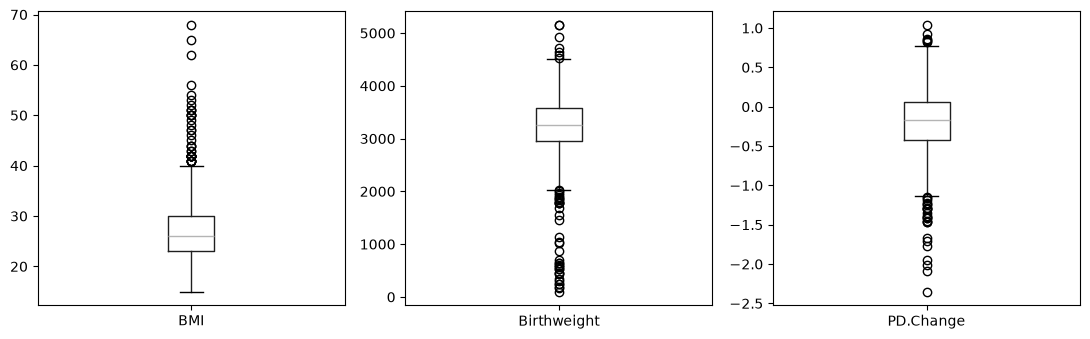

In [42]:
plt.figure(figsize=(11, 3.5))

plt.subplot(1, 3, 1)
df.boxplot(column='BMI', grid=False)

plt.subplot(1, 3, 2)
df.boxplot(column='Birthweight', grid=False)

plt.subplot(1, 3, 3)
df.boxplot(column='PD.Change', grid=False)

plt.tight_layout()
plt.show()

In [43]:
df_clean = df[~((df['PD.Change'] < lower) | (df['PD.Change'] > upper))]
print('rows before =', len(df))
print('rows after removing outliers =', len(df_clean))

rows before = 823
rows after removing outliers = 792


In [44]:
df_clean[['PID', 'Clinic', 'Group', 'Age', 'Age.Group', 'BMI', 'BMI.Category',
          'BL.PD.avg', 'V5.PD.avg', 'PD.Change', 'PD.Quartile', 'Birthweight']].head()

,PID,Clinic,Group,Age,Age.Group,BMI,BMI.Category,BL.PD.avg,V5.PD.avg,PD.Change,PD.Quartile,Birthweight
0,100034,NY,Control,25,25-29,26.0,Overweight,2.696,2.929,0.233,Q2,3490.0
1,100042,NY,Control,21,20-24,21.0,Normal,2.685,NaN,NaN,Q2,2350.0
2,100067,NY,Treatment,25,25-29,24.0,Normal,2.821,NaN,NaN,Q3,2525.0
4,100091,NY,Control,21,20-24,27.0,Overweight,2.768,2.786,0.018,Q3,3865.0
5,100109,NY,Treatment,40,35+,24.0,Normal,2.932,NaN,NaN,Q3,3120.0


In [45]:
df_clean.to_csv('opt_transformed.csv', index=False)
print('saved opt_transformed.csv')
print(df_clean.shape)

saved opt_transformed.csv
(792, 176)


In [46]:
num = ['Age', 'BMI', 'N.qualifying.teeth', 'BL.GE', 'BL..BOP', 'BL.PD.avg',
       'BL.CAL.avg', 'BL.Calc.I', 'BL.Pl.I', 'V5.PD.avg',
       'GA.at.outcome', 'Birthweight', 'Apgar1', 'Apgar5']
df_clean[num].dtypes

Age                     int64
BMI                   float64
N.qualifying.teeth      int64
BL.GE                 float64
BL..BOP               float64
BL.PD.avg             float64
BL.CAL.avg            float64
BL.Calc.I             float64
BL.Pl.I               float64
V5.PD.avg             float64
GA.at.outcome           int64
Birthweight           float64
Apgar1                float64
Apgar5                float64
dtype: object

In [47]:
mean = df_clean['Birthweight'].mean()
median = df_clean['Birthweight'].median()
mode = df_clean['Birthweight'].mode()

print('mean =', mean)
print('median =', median)
print('mode =', mode[0])

mean = 3197.0244215938305
median = 3268.0
mode = 3190.0


In [48]:
print('standard deviation =', df_clean['Birthweight'].std())
print('variance =', df_clean['Birthweight'].var())
print('minimum =', df_clean['Birthweight'].min())
print('maximum =', df_clean['Birthweight'].max())
print('range =', df_clean['Birthweight'].max() - df_clean['Birthweight'].min())
print('Q1 =', df_clean['Birthweight'].quantile(0.25))
print('Q3 =', df_clean['Birthweight'].quantile(0.75))

standard deviation = 689.4840222267921
variance = 475388.21690603567
minimum = 101.0
maximum = 5160.0
range = 5059.0
Q1 = 2966.25
Q3 = 3578.75


In [49]:
df_clean[num].agg(['mean', 'median', 'std', 'var', 'min', 'max']).round(2).T

,mean,median,std,var,min,max
Age,25.94,25.00,5.57,31.08,16.00,44.00
BMI,27.46,26.00,6.83,46.63,15.00,68.00
N.qualifying.teeth,14.47,13.00,6.57,43.14,3.00,28.00
BL.GE,1.42,1.40,0.41,0.17,0.43,3.00
BL..BOP,68.73,68.10,17.08,291.72,33.95,100.00
BL.PD.avg,2.83,2.71,0.51,0.26,1.85,6.08
BL.CAL.avg,1.38,1.33,0.66,0.44,0.18,5.12
BL.Calc.I,1.11,1.03,0.60,0.36,0.00,2.69
BL.Pl.I,1.22,1.22,0.48,0.23,0.06,2.78
V5.PD.avg,2.64,2.56,0.49,0.24,1.54,5.43


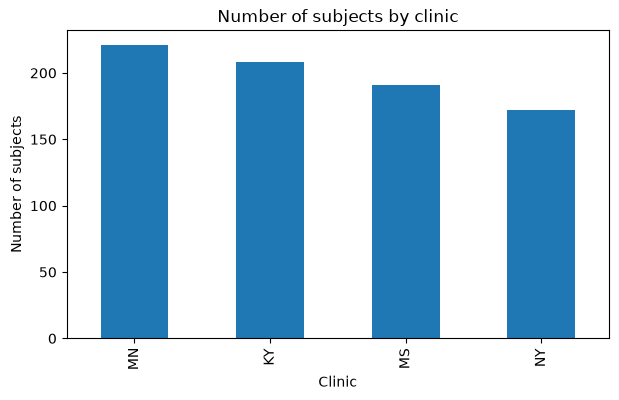

In [50]:
df_clean['Clinic'].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title('Number of subjects by clinic')
plt.xlabel('Clinic')
plt.ylabel('Number of subjects')
plt.show()

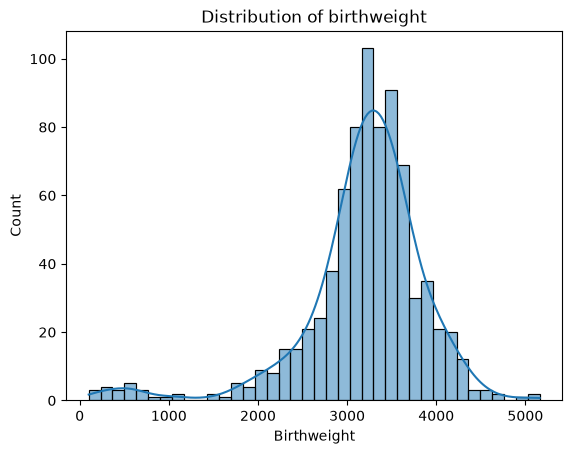

In [51]:
sns.histplot(data=df_clean, x='Birthweight', kde=True)
plt.title('Distribution of birthweight')
plt.show()

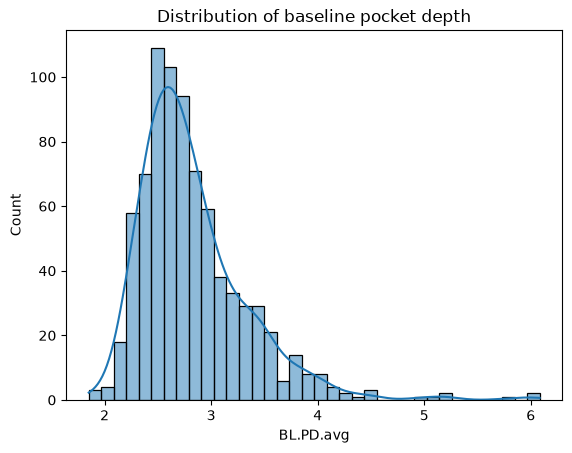

In [52]:
sns.histplot(data=df_clean, x='BL.PD.avg', kde=True)
plt.title('Distribution of baseline pocket depth')
plt.show()

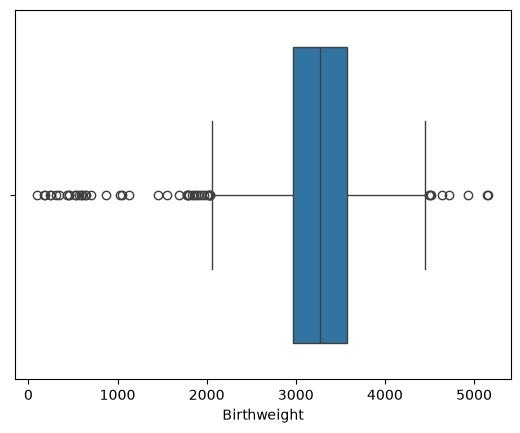

In [53]:
sns.boxplot(x='Birthweight', data=df_clean)
plt.show()

In [54]:
bi = df_clean[['GA.at.outcome', 'Birthweight', 'BL.PD.avg', 'BL.Calc.I', 'Apgar1']].dropna()
bi.head()

,GA.at.outcome,Birthweight,BL.PD.avg,BL.Calc.I,Apgar1
0,265,3490.0,2.696,1.028,9.0
1,253,2350.0,2.685,0.861,4.0
2,266,2525.0,2.821,0.972,8.0
4,280,3865.0,2.768,1.111,9.0
5,275,3120.0,2.932,0.194,8.0


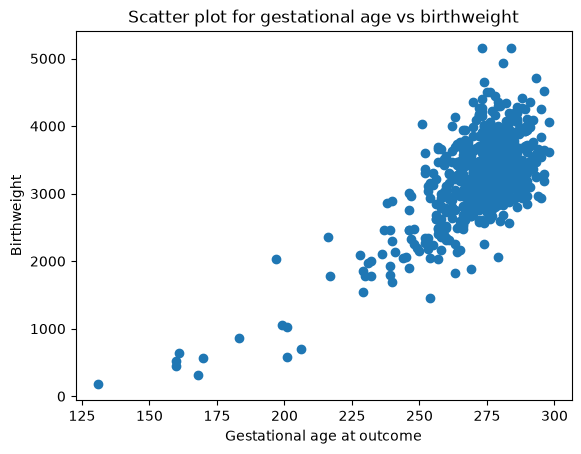

In [55]:
plt.scatter(bi['GA.at.outcome'], bi['Birthweight'])
plt.title('Scatter plot for gestational age vs birthweight')
plt.xlabel('Gestational age at outcome')
plt.ylabel('Birthweight')
plt.show()

In [56]:
np.corrcoef(bi['GA.at.outcome'], bi['Birthweight'])

array([[1.        , 0.70140348],
       [0.70140348, 1.        ]])

In [57]:
np.corrcoef(bi['BL.Calc.I'], bi['Apgar1'])

array([[ 1.        , -0.14398566],
       [-0.14398566,  1.        ]])

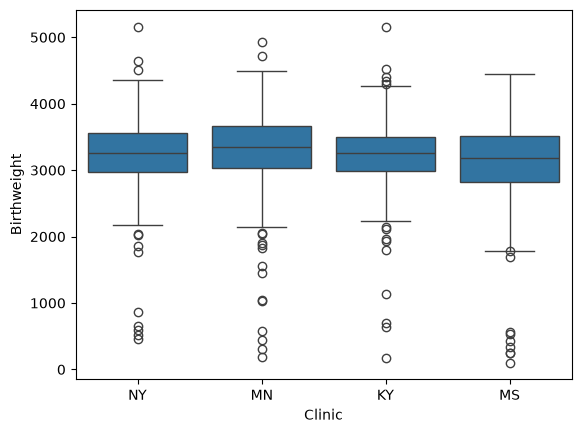

In [58]:
sns.boxplot(x='Clinic', y='Birthweight', data=df_clean)
plt.show()

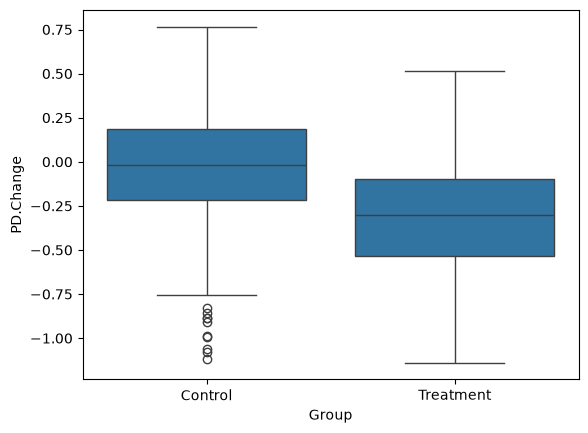

In [59]:
sns.boxplot(x='Group', y='PD.Change', data=df_clean)
plt.show()

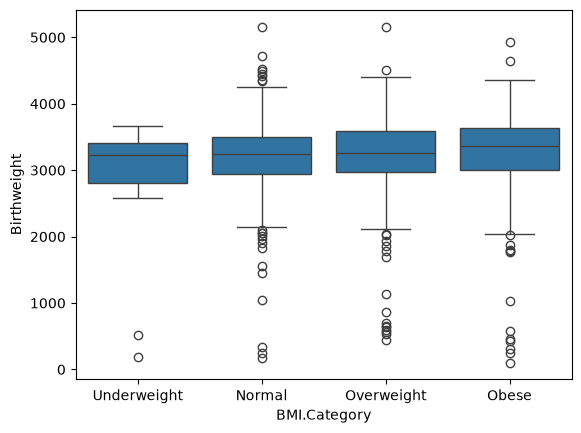

In [60]:
sns.boxplot(x='BMI.Category', y='Birthweight', data=df_clean)
plt.show()

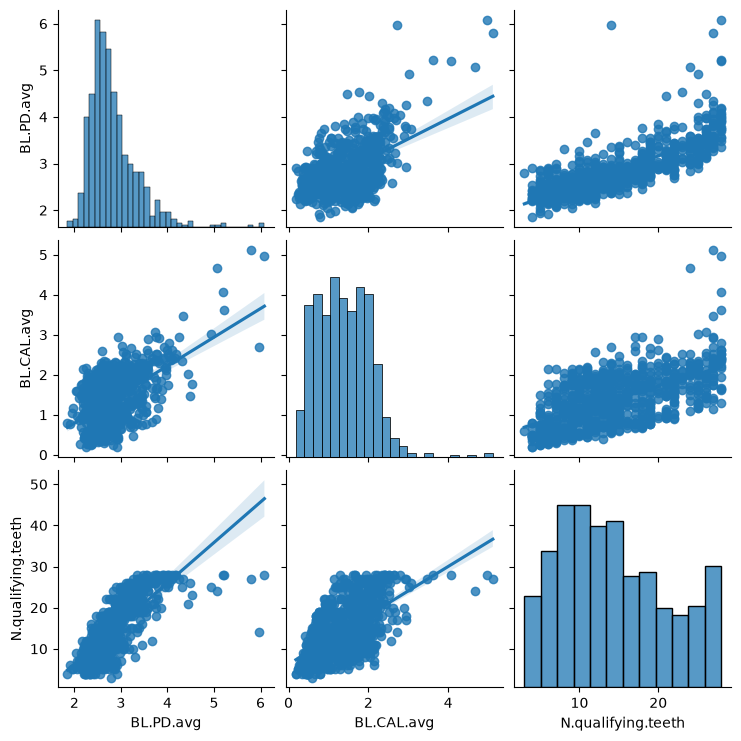

In [61]:
sns.pairplot(df_clean, vars=['BL.PD.avg', 'BL.CAL.avg', 'N.qualifying.teeth'], kind='reg')
plt.show()

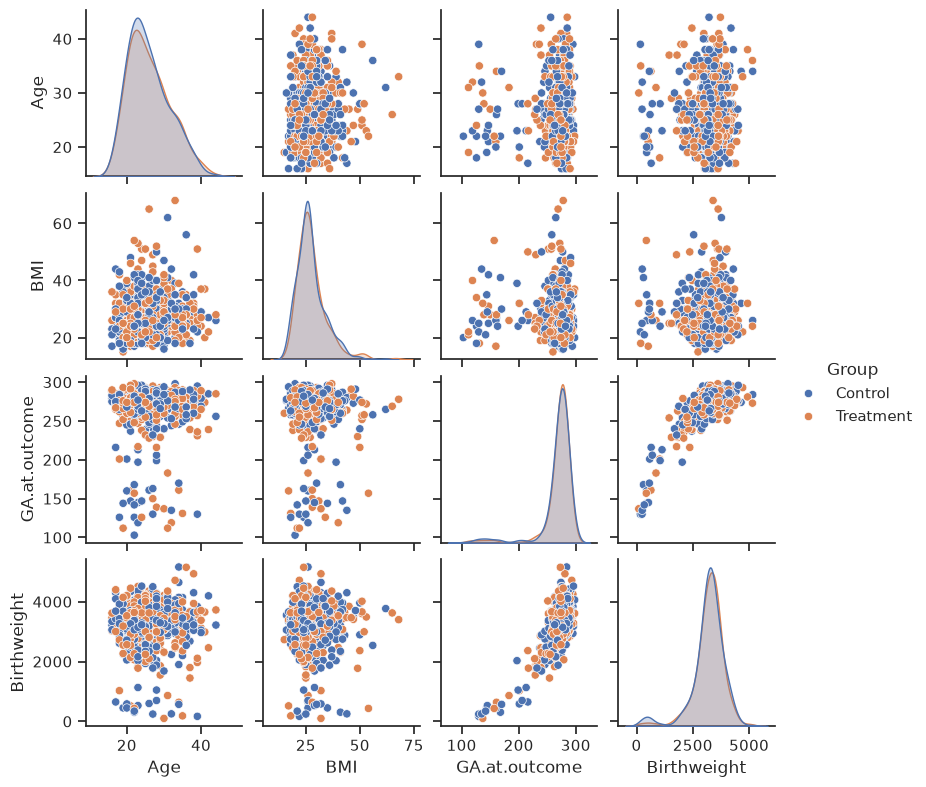

In [62]:
sns.set(style='ticks', color_codes=True)
sns.pairplot(df_clean, height=2, vars=['Age', 'BMI', 'GA.at.outcome', 'Birthweight'], hue='Group')
plt.show()

In [63]:
corr = stats.pearsonr(bi['GA.at.outcome'], bi['Birthweight'])
print('cor:\t\t', corr[0])
print('p-value:\t', corr[1])

cor:		 0.7014034846678581
p-value:	 2.982393994262665e-112


In [64]:
correlation = df_clean[num].corr(method='pearson', numeric_only=True)
correlation.round(2)

,Age,BMI,N.qualifying.teeth,BL.GE,BL..BOP,BL.PD.avg,BL.CAL.avg,BL.Calc.I,BL.Pl.I,V5.PD.avg,GA.at.outcome,Birthweight,Apgar1,Apgar5
Age,1.00,0.11,0.13,0.14,0.13,0.20,0.23,0.25,0.10,0.09,-0.01,0.02,-0.06,-0.03
BMI,0.11,1.00,0.04,0.10,0.07,0.03,0.18,-0.01,0.10,-0.01,-0.07,0.01,-0.01,-0.03
N.qualifying.teeth,0.13,0.04,1.00,0.30,0.46,0.77,0.60,0.42,0.33,0.56,-0.01,-0.03,-0.05,-0.02
BL.GE,0.14,0.10,0.30,1.00,0.66,0.37,0.53,0.59,0.55,0.34,0.04,0.04,0.04,0.07
BL..BOP,0.13,0.07,0.46,0.66,1.00,0.54,0.41,0.55,0.50,0.45,-0.01,0.00,0.01,0.04
BL.PD.avg,0.20,0.03,0.77,0.37,0.54,1.00,0.56,0.53,0.42,0.73,0.04,0.03,-0.09,-0.03
BL.CAL.avg,0.23,0.18,0.60,0.53,0.41,0.56,1.00,0.38,0.34,0.41,-0.04,-0.07,0.03,0.05
BL.Calc.I,0.25,-0.01,0.42,0.59,0.55,0.53,0.38,1.00,0.63,0.49,0.08,0.05,-0.14,-0.05
BL.Pl.I,0.10,0.10,0.33,0.55,0.50,0.42,0.34,0.63,1.00,0.36,0.02,-0.00,-0.07,-0.03
V5.PD.avg,0.09,-0.01,0.56,0.34,0.45,0.73,0.41,0.49,0.36,1.00,0.07,0.02,-0.08,-0.04


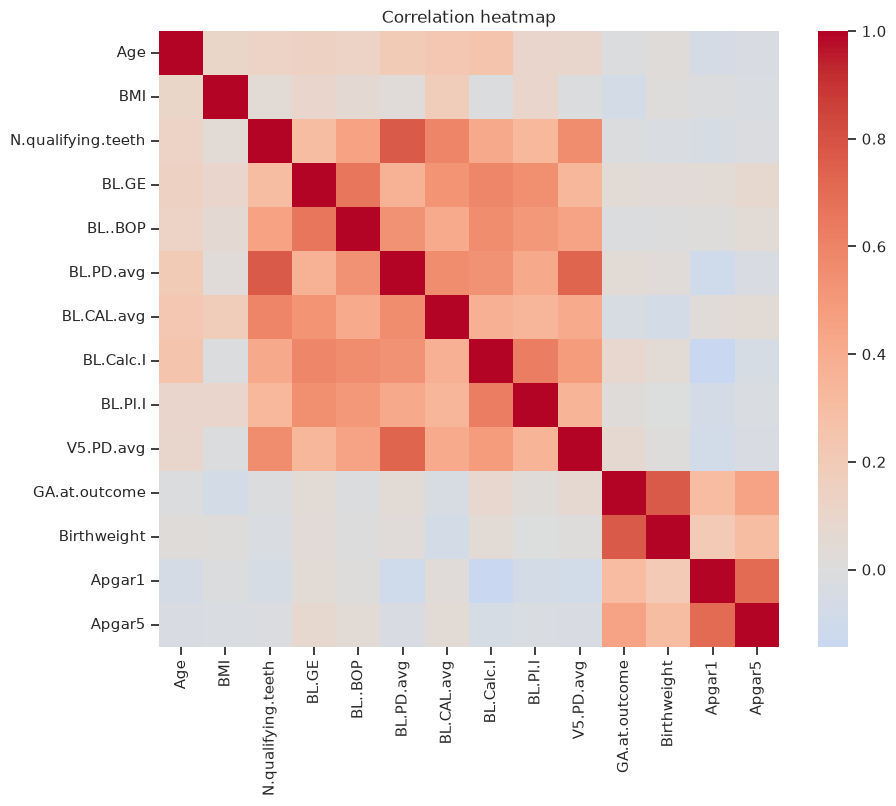

In [65]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, xticklabels=correlation.columns,
            yticklabels=correlation.columns, cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

In [66]:
correlation['Birthweight'].sort_values(ascending=False)

Birthweight           1.000000
GA.at.outcome         0.769855
Apgar5                0.304849
Apgar1                0.205553
BL.Calc.I             0.045912
BL.GE                 0.038881
BL.PD.avg             0.032751
Age                   0.023518
V5.PD.avg             0.016542
BMI                   0.009445
BL..BOP               0.003892
BL.Pl.I              -0.001192
N.qualifying.teeth   -0.025845
BL.CAL.avg           -0.069193
Name: Birthweight, dtype: float64

# 1D Statistical Analysis

In [67]:
one_d_columns = ['Age', 'BMI', 'Birthweight', 'GA.at.outcome', 'BL.PD.avg', 'PD.Change']
one_d_summary = df_clean[one_d_columns].agg(['count', 'mean', 'median', 'std', 'var', 'min', 'max', 'skew']).T
one_d_summary['mode'] = df_clean[one_d_columns].mode().iloc[0]
one_d_summary['range'] = one_d_summary['max'] - one_d_summary['min']
one_d_summary['Q1'] = df_clean[one_d_columns].quantile(0.25)
one_d_summary['Q3'] = df_clean[one_d_columns].quantile(0.75)
one_d_summary['IQR'] = one_d_summary['Q3'] - one_d_summary['Q1']
one_d_summary['kurtosis'] = df_clean[one_d_columns].kurtosis()
one_d_summary = one_d_summary[['count', 'mean', 'median', 'mode', 'std', 'var', 'min', 'max', 'range', 'Q1', 'Q3', 'IQR', 'skew', 'kurtosis']]
one_d_summary.round(2)

,count,mean,median,mode,std,var,min,max,range,Q1,Q3,IQR,skew,kurtosis
Age,792.0,25.94,25.00,23.00,5.57,31.08,16.00,44.00,28.00,22.00,30.00,8.00,0.61,-0.22
BMI,792.0,27.46,26.00,26.00,6.83,46.63,15.00,68.00,53.00,23.00,30.00,7.00,1.63,4.57
Birthweight,778.0,3197.02,3268.00,3190.00,689.48,475388.22,101.00,5160.00,5059.00,2966.25,3578.75,612.50,-1.59,5.00
GA.at.outcome,792.0,268.28,275.00,280.00,28.67,821.87,103.00,298.00,195.00,267.00,281.00,14.00,-3.58,13.89
BL.PD.avg,792.0,2.83,2.71,2.57,0.51,0.26,1.85,6.08,4.23,2.49,3.04,0.55,1.86,6.40
PD.Change,628.0,-0.17,-0.15,0.00,0.36,0.13,-1.14,0.77,1.91,-0.39,0.06,0.45,-0.31,0.09


In [68]:
birthweight = df_clean['Birthweight'].dropna()
birthweight_frequency = pd.cut(birthweight, bins=10).value_counts().sort_index()
pd.DataFrame({'Frequency': birthweight_frequency,
              'Cumulative Frequency': birthweight_frequency.cumsum(),
              'Relative Frequency': birthweight_frequency / birthweight_frequency.sum()})

,Frequency,Cumulative Frequency,Relative Frequency
Birthweight,,,
"(95.941, 606.9]",15,15,0.019280
"(606.9, 1112.8]",6,21,0.007712
"(1112.8, 1618.7]",3,24,0.003856
"(1618.7, 2124.6]",20,44,0.025707
"(2124.6, 2630.5]",58,102,0.074550
"(2630.5, 3136.4]",189,291,0.242931
"(3136.4, 3642.3]",326,617,0.419023
"(3642.3, 4148.2]",127,744,0.163239
"(4148.2, 4654.1]",30,774,0.038560


In [69]:
one_d_categories = ['Clinic', 'Group', 'BMI.Category', 'Birth.outcome']
for column in one_d_categories:
    print(column)
    print(df_clean[column].value_counts(dropna=False))
    print()

Clinic
Clinic
MN    221
KY    208
MS    191
NY    172
Name: count, dtype: int64

Group
Group
Control      402
Treatment    390
Name: count, dtype: int64

BMI.Category
BMI.Category
Normal         299
Overweight     281
Obese          186
Underweight     26
Name: count, dtype: int64

Birth.outcome
Birth.outcome
Live birth           762
Non-live birth        19
Lost to FU             9
Elective abortion      2
Name: count, dtype: int64



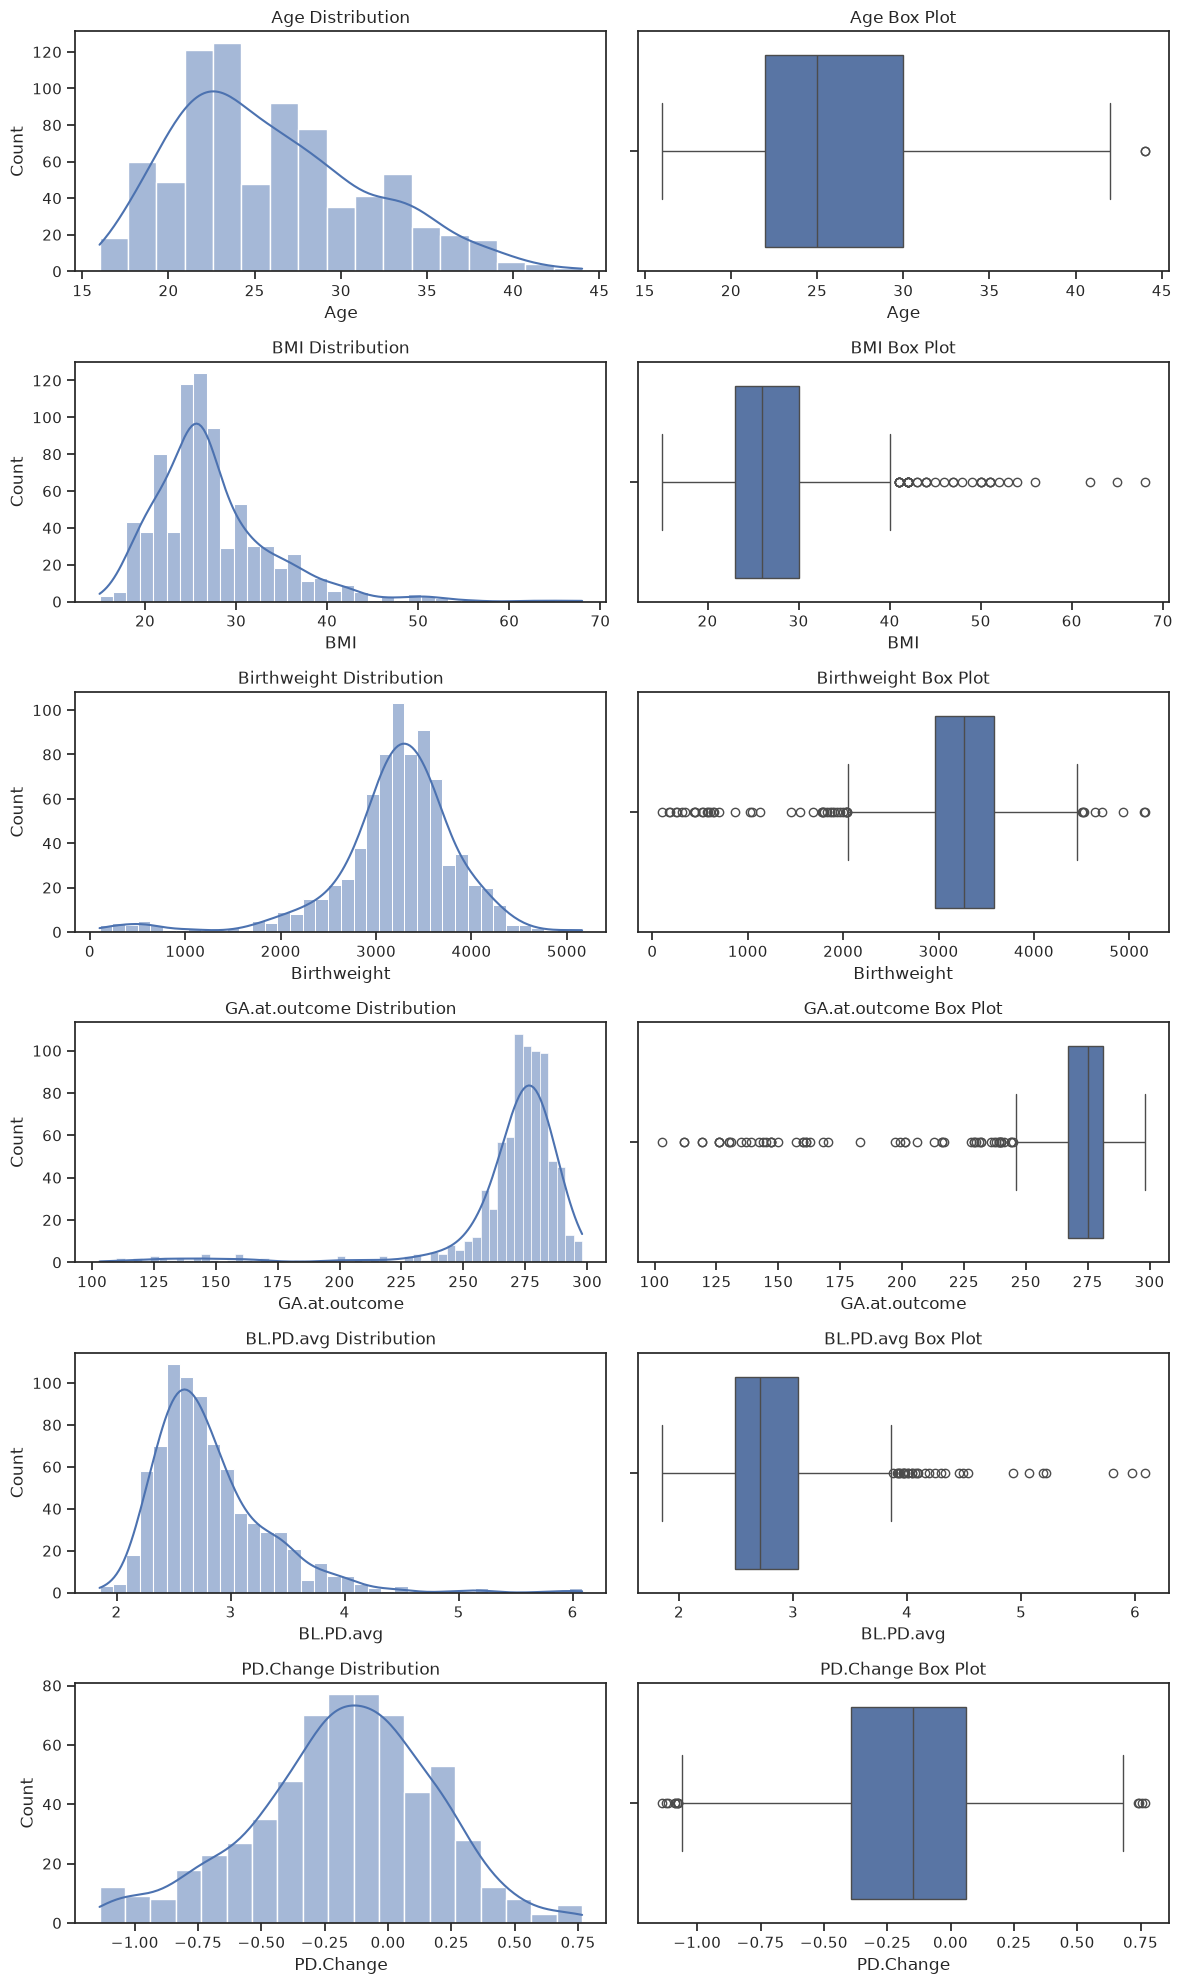

In [70]:
fig, axes = plt.subplots(len(one_d_columns), 2, figsize=(12, 20))
for i, column in enumerate(one_d_columns):
    sns.histplot(df_clean[column].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(column + ' Distribution')
    sns.boxplot(x=df_clean[column], ax=axes[i, 1])
    axes[i, 1].set_title(column + ' Box Plot')
plt.tight_layout()
plt.show()

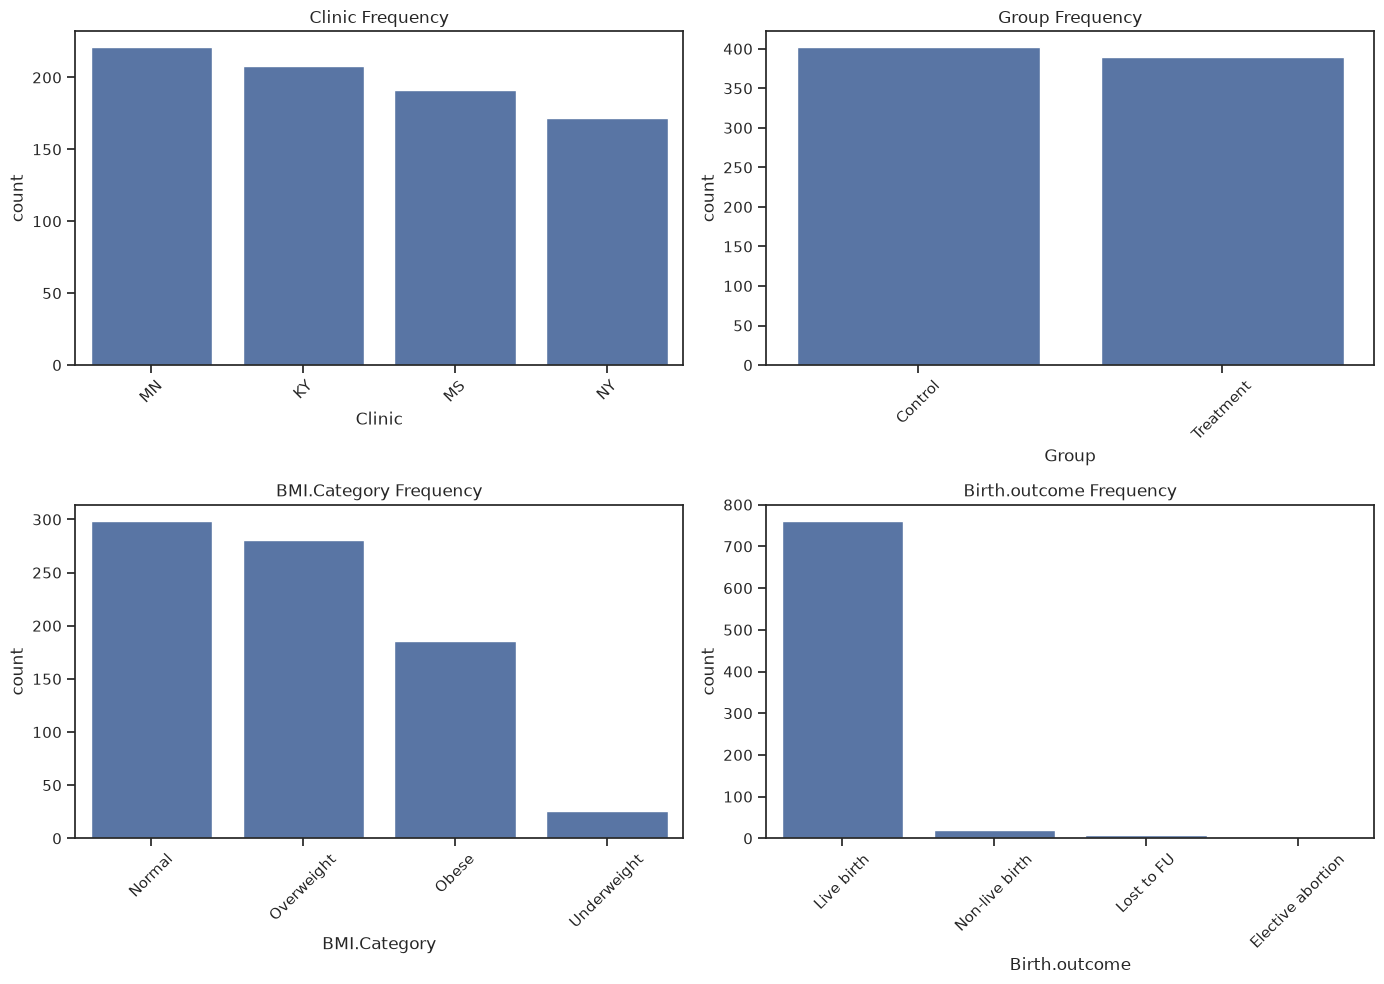

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for column, ax in zip(one_d_categories, axes.flatten()):
    sns.countplot(data=df_clean, x=column, order=df_clean[column].value_counts().index, ax=ax)
    ax.set_title(column + ' Frequency')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

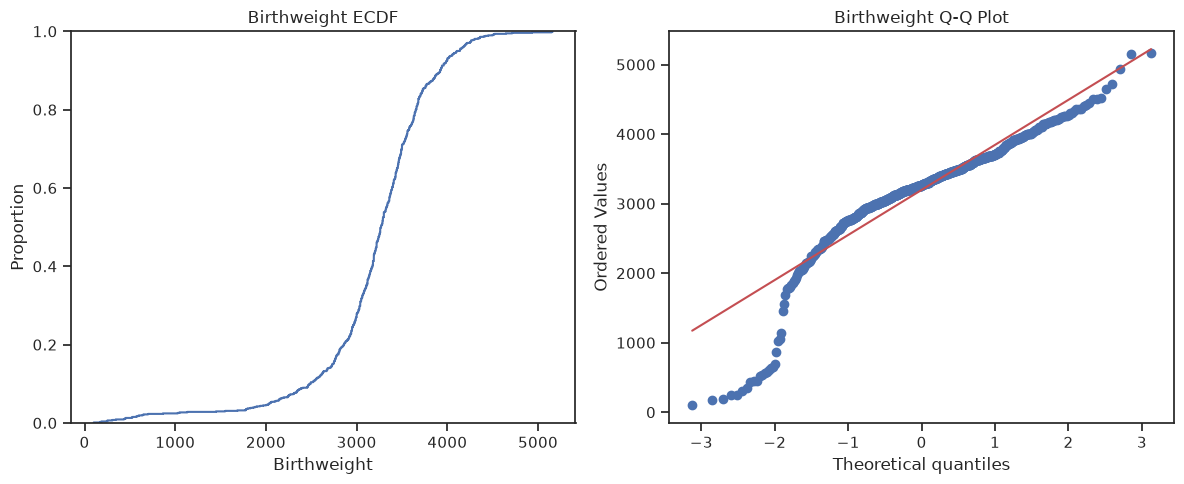

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.ecdfplot(x=birthweight, ax=axes[0])
axes[0].set_title('Birthweight ECDF')
stats.probplot(birthweight, dist='norm', plot=axes[1])
axes[1].set_title('Birthweight Q-Q Plot')
plt.tight_layout()
plt.show()

# 2D Statistical Analysis

In [ ]:
two_d_numeric = df_clean[['GA.at.outcome', 'Birthweight']].dropna()
pearson_result = stats.pearsonr(two_d_numeric['GA.at.outcome'], two_d_numeric['Birthweight'])
spearman_result = stats.spearmanr(two_d_numeric['GA.at.outcome'], two_d_numeric['Birthweight'])
print('Covariance')
print(two_d_numeric.cov().round(2))
print('Pearson correlation =', pearson_result.statistic)
print('Pearson p-value =', pearson_result.pvalue)
print('Spearman correlation =', spearman_result.statistic)
print('Spearman p-value =', spearman_result.pvalue)

In [ ]:
sns.regplot(data=two_d_numeric, x='GA.at.outcome', y='Birthweight', scatter_kws={'alpha': 0.5})
plt.title('Gestational Age and Birthweight')
plt.show()

In [ ]:
group_pd = df_clean[['Group', 'PD.Change']].dropna()
control_pd = group_pd.loc[group_pd['Group'] == 'Control', 'PD.Change']
treatment_pd = group_pd.loc[group_pd['Group'] == 'Treatment', 'PD.Change']
t_test = stats.ttest_ind(control_pd, treatment_pd, equal_var=False)
mann_whitney = stats.mannwhitneyu(control_pd, treatment_pd, alternative='two-sided')
print(group_pd.groupby('Group')['PD.Change'].agg(['count', 'mean', 'median', 'std']).round(3))
print('Welch t-test statistic =', t_test.statistic)
print('Welch t-test p-value =', t_test.pvalue)
print('Mann-Whitney statistic =', mann_whitney.statistic)
print('Mann-Whitney p-value =', mann_whitney.pvalue)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=group_pd, x='Group', y='PD.Change', ax=axes[0])
sns.violinplot(data=group_pd, x='Group', y='PD.Change', ax=axes[1])
axes[0].set_title('PD Change by Group')
axes[1].set_title('PD Change Distribution by Group')
plt.tight_layout()
plt.show()

In [ ]:
group_preterm = df_clean[['Group', 'Preg.ended...37.wk']].dropna()
preterm_table = pd.crosstab(group_preterm['Group'], group_preterm['Preg.ended...37.wk'])
chi_square = stats.chi2_contingency(preterm_table)
print(preterm_table)
print('Chi-square statistic =', chi_square.statistic)
print('Chi-square p-value =', chi_square.pvalue)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(preterm_table, annot=True, fmt='d', cmap='Blues', ax=axes[0])
preterm_table.plot(kind='bar', stacked=True, ax=axes[1])
axes[0].set_title('Group and Preterm Pregnancy')
axes[1].set_title('Preterm Pregnancy by Group')
plt.tight_layout()
plt.show()

# 3D Statistical Analysis

In [ ]:
three_d_columns = ['GA.at.outcome', 'BMI', 'Birthweight']
three_d = df_clean[three_d_columns + ['Group']].dropna()
print(three_d[three_d_columns].describe().round(2))
print(three_d[three_d_columns].corr().round(3))

In [ ]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for group, color in [('Control', 'blue'), ('Treatment', 'orange')]:
    group_data = three_d[three_d['Group'] == group]
    ax.scatter(group_data['GA.at.outcome'], group_data['BMI'], group_data['Birthweight'], color=color, alpha=0.6, label=group)
ax.set_xlabel('Gestational Age')
ax.set_ylabel('BMI')
ax.set_zlabel('Birthweight')
ax.set_title('Gestational Age, BMI and Birthweight')
ax.legend()
plt.show()

In [ ]:
X = np.column_stack((np.ones(len(three_d)), three_d['GA.at.outcome'], three_d['BMI']))
y = three_d['Birthweight'].to_numpy()
coefficients = np.linalg.lstsq(X, y, rcond=None)[0]
predicted = X @ coefficients
r_squared = 1 - np.sum((y - predicted) ** 2) / np.sum((y - y.mean()) ** 2)
print('Intercept =', coefficients[0])
print('Gestational age coefficient =', coefficients[1])
print('BMI coefficient =', coefficients[2])
print('R-squared =', r_squared)

In [ ]:
ga_grid, bmi_grid = np.meshgrid(np.linspace(three_d['GA.at.outcome'].min(), three_d['GA.at.outcome'].max(), 20), np.linspace(three_d['BMI'].min(), three_d['BMI'].max(), 20))
birthweight_grid = coefficients[0] + coefficients[1] * ga_grid + coefficients[2] * bmi_grid
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(three_d['GA.at.outcome'], three_d['BMI'], three_d['Birthweight'], alpha=0.4)
ax.plot_surface(ga_grid, bmi_grid, birthweight_grid, alpha=0.4, color='orange')
ax.set_xlabel('Gestational Age')
ax.set_ylabel('BMI')
ax.set_zlabel('Birthweight')
ax.set_title('Multiple Linear Regression Plane')
plt.show()

In [ ]:
clinic_group_birthweight = df_clean.pivot_table(values='Birthweight', index='Clinic', columns='Group', aggfunc='mean')
print(clinic_group_birthweight.round(2))
sns.heatmap(clinic_group_birthweight, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Mean Birthweight by Clinic and Group')
plt.show()

In [ ]:
three_way_table = pd.crosstab([df_clean['Clinic'], df_clean['Group']], df_clean['Preg.ended...37.wk'])
three_way_table